In [7]:
import pandas as pd
import numpy as np

# Define column names
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"
]

# Load dataset with column names
data = pd.read_csv('adult.data.csv', names=columns)

# Exploration
print(f"Format du dataset : {data.shape}")
print(data['income'].value_counts(normalize=True))

Format du dataset : (32561, 15)
income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [8]:
def calculate_entropy(df, target_col):
    probs = df[target_col].value_counts(normalize=True)
    return -sum(p * np.log2(p) for p in probs)

# Entropie pour chaque valeur de 'education'
education_values = data['education'].unique()
for val in education_values:
    subset = data[data['education'] == val]
    entropy = calculate_entropy(subset, 'income')
    print(f"Entropie pour {val:<15} : {entropy:.4f}")

Entropie pour  Bachelors      : 0.9789
Entropie pour  HS-grad        : 0.6331
Entropie pour  11th           : 0.2909
Entropie pour  Masters        : 0.9907
Entropie pour  9th            : 0.2970
Entropie pour  Some-college   : 0.7020
Entropie pour  Assoc-acdm     : 0.8087
Entropie pour  Assoc-voc      : 0.8286
Entropie pour  7th-8th        : 0.3350
Entropie pour  Doctorate      : 0.8254
Entropie pour  Prof-school    : 0.8351
Entropie pour  5th-6th        : 0.2780
Entropie pour  10th           : 0.3525
Entropie pour  1st-4th        : 0.2223
Entropie pour  Preschool      : -0.0000
Entropie pour  12th           : 0.3887


In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, cross_validate 
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
confusion_matrix, ConfusionMatrixDisplay, 
roc_curve, auc, precision_recall_curve, average_precision_score) 
plt.rcParams['figure.figsize'] = (12, 8) 
plt.rcParams['font.size'] = 12 
sns.set_style("whitegrid") 
print("✅ Bibliothèques chargées") 


✅ Bibliothèques chargées


In [15]:
column_names = [ 
    "age", "workclass", "fnlwgt", "education", "education_num", 
    "marital_status", "occupation", "relationship", "race", 
    "sex", "capital_gain", "capital_loss", "hours_per_week", 
    "native_country", "income" 
] 

try: 
    # Le bloc ci-dessous DOIT être indenté (4 espaces ou 1 tabulation)
    data = pd.read_csv("adult.data", header=None, names=column_names, 
                       na_values="?", skipinitialspace=True) 
    print(f"✅ Dataset chargé : {data.shape}") 
except: 
    # Le bloc ci-dessous DOIT aussi être indenté
    print("❌ Fichier non trouvé")

❌ Fichier non trouvé


In [16]:
print(f"✅ Dataset chargé : {data.shape}")

✅ Dataset chargé : (32561, 15)


In [19]:
# ==========================================
# 1. ENCODAGE (À FAIRE EN PREMIER)
# ==========================================

# Encodage de la variable cible 'income' (<=50K -> 0, >50K -> 1)
le_income = LabelEncoder()
data["income"] = le_income.fit_transform(data["income"])

# Identification automatique des colonnes textuelles (catégorielles)
cat_features = data.select_dtypes(include=["object"]).columns

# Application du LabelEncoder sur chaque colonne textuelle pour les transformer en nombres
for col in cat_features:
    data[col] = LabelEncoder().fit_transform(data[col])

print("✅ Encodage terminé : toutes les données sont maintenant numériques.")

# ==========================================
# 2. SPLIT ET ENTRAÎNEMENT (APRÈS ENCODAGE)
# ==========================================

# Définition des caractéristiques (X) et de la cible (y)
X = data.drop('income', axis=1) 
y = data['income'] 

# Division du dataset en 70% train et 30% test avec stratification
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.3, random_state=42, stratify=y 
) 

# --- Modèle GINI (CART) ---
clf_gini = DecisionTreeClassifier(random_state=42, max_depth=5) 
clf_gini.fit(X_train, y_train) 
y_pred_gini = clf_gini.predict(X_test) 
y_proba_gini = clf_gini.predict_proba(X_test)[:, 1] 

# --- Modèle ENTROPIE (ID3/C4.5) ---
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5) 
clf_entropy.fit(X_train, y_train) 
y_pred_entropy = clf_entropy.predict(X_test) 
y_proba_entropy = clf_entropy.predict_proba(X_test)[:, 1]

print("✅ Modèles entraînés avec succès !")

✅ Encodage terminé : toutes les données sont maintenant numériques.
✅ Modèles entraînés avec succès !


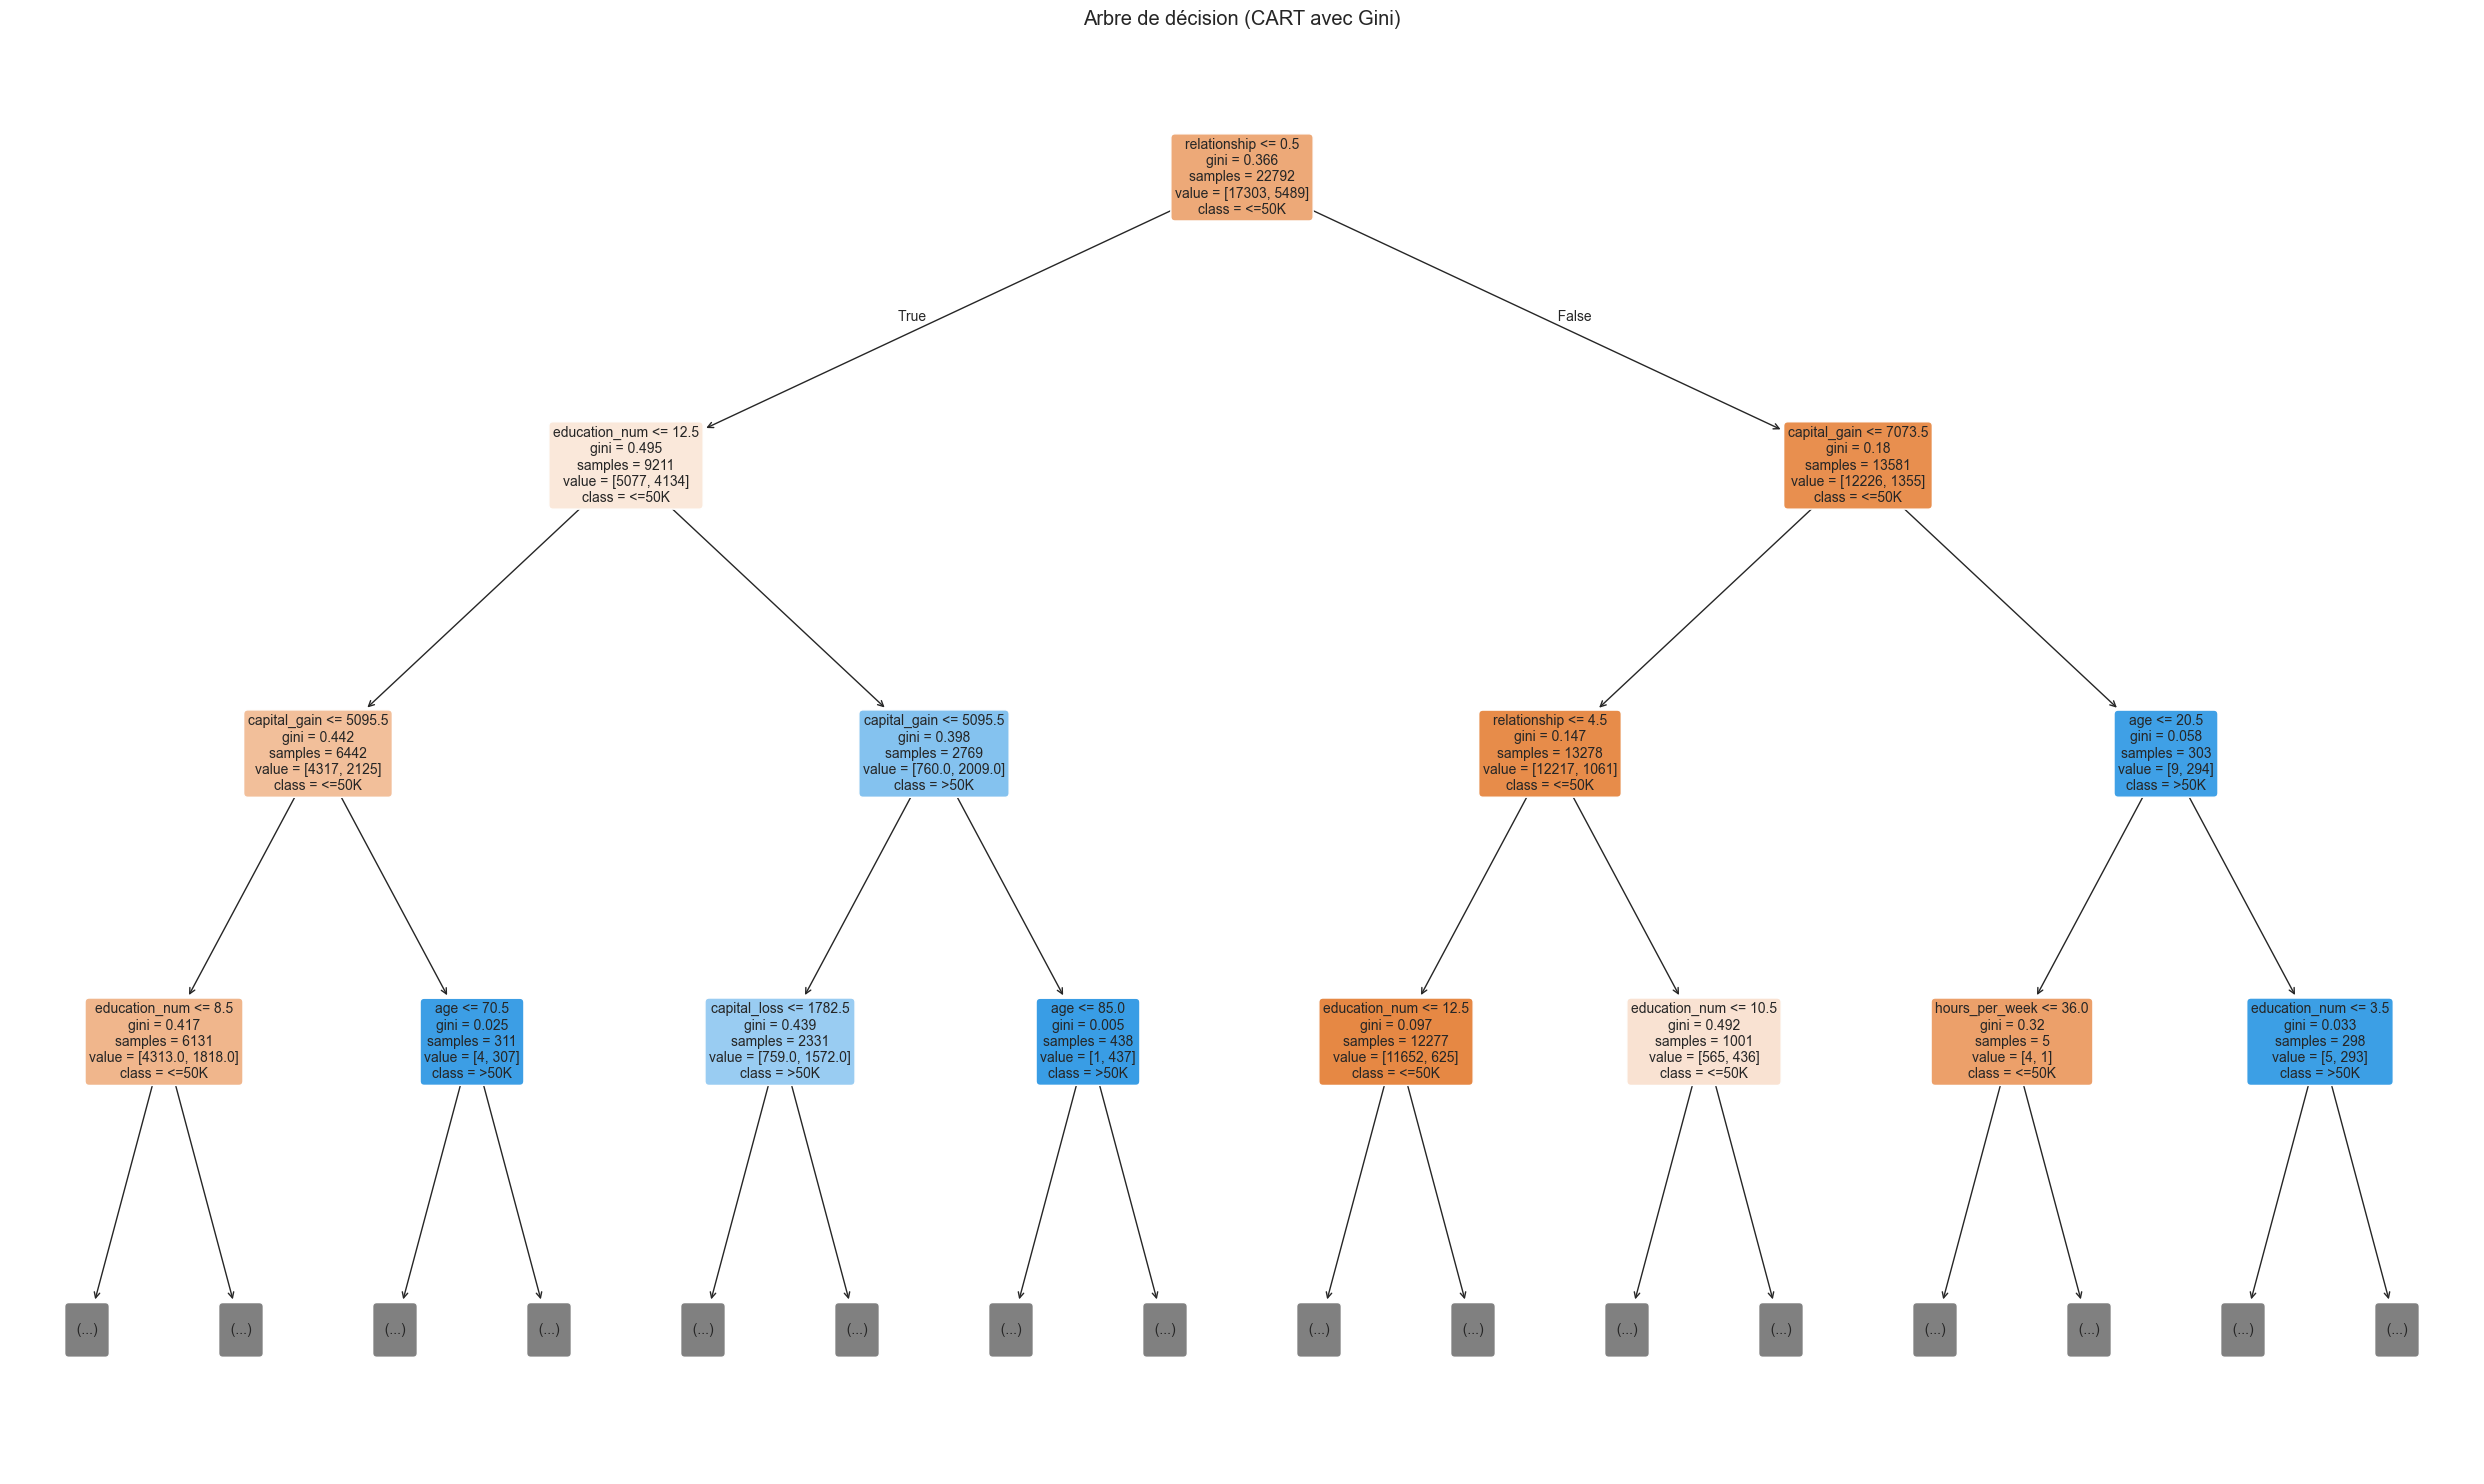

In [20]:

plt.figure(figsize=(25, 15)) 
plot_tree(clf_gini, feature_names=X.columns,  
class_names=['<=50K', '>50K'],  
filled=True, rounded=True,  
fontsize=10, max_depth=3) 
plt.title("Arbre de décision (CART avec Gini)") 
plt.tight_layout() 
plt.show() 


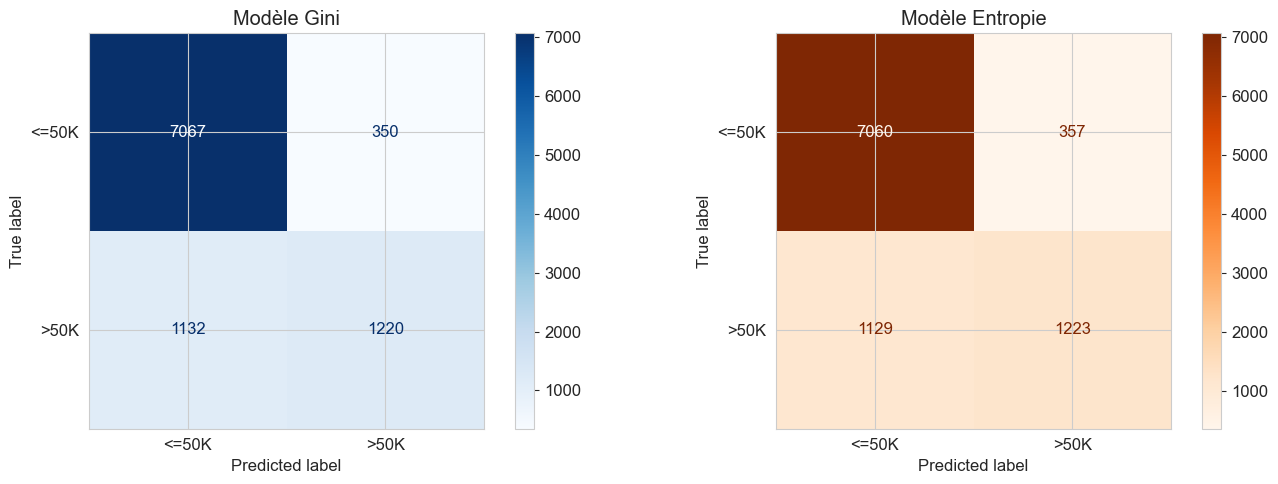

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
cm_gini = confusion_matrix(y_test, y_pred_gini) 
ConfusionMatrixDisplay(cm_gini, display_labels=['<=50K', '>50K']).plot(ax=axes[0], cmap='Blues') 
axes[0].set_title('Modèle Gini') 
cm_entropy = confusion_matrix(y_test, y_pred_entropy) 
ConfusionMatrixDisplay(cm_entropy, display_labels=['<=50K', '>50K']).plot(ax=axes[1], cmap='Oranges') 
axes[1].set_title('Modèle Entropie') 
plt.tight_layout() 
plt.show() 

In [22]:
# 2. Rapport de performance comparatif
metrics_data = {
    "Métrique": ["Accuracy", "Précision", "Rappel", "F1-Score"],
    "Modèle Gini": [
        accuracy_score(y_test, y_pred_gini),
        precision_score(y_test, y_pred_gini),
        recall_score(y_test, y_pred_gini),
        f1_score(y_test, y_pred_gini)
    ],
    "Modèle Entropie": [
        accuracy_score(y_test, y_pred_entropy),
        precision_score(y_test, y_pred_entropy),
        recall_score(y_test, y_pred_entropy),
        f1_score(y_test, y_pred_entropy)
    ]
}

df_perf = pd.DataFrame(metrics_data)
print("📊 Tableau des Performances :")
print(df_perf.round(3))

📊 Tableau des Performances :
    Métrique  Modèle Gini  Modèle Entropie
0   Accuracy        0.848            0.848
1  Précision        0.777            0.774
2     Rappel        0.519            0.520
3   F1-Score        0.622            0.622


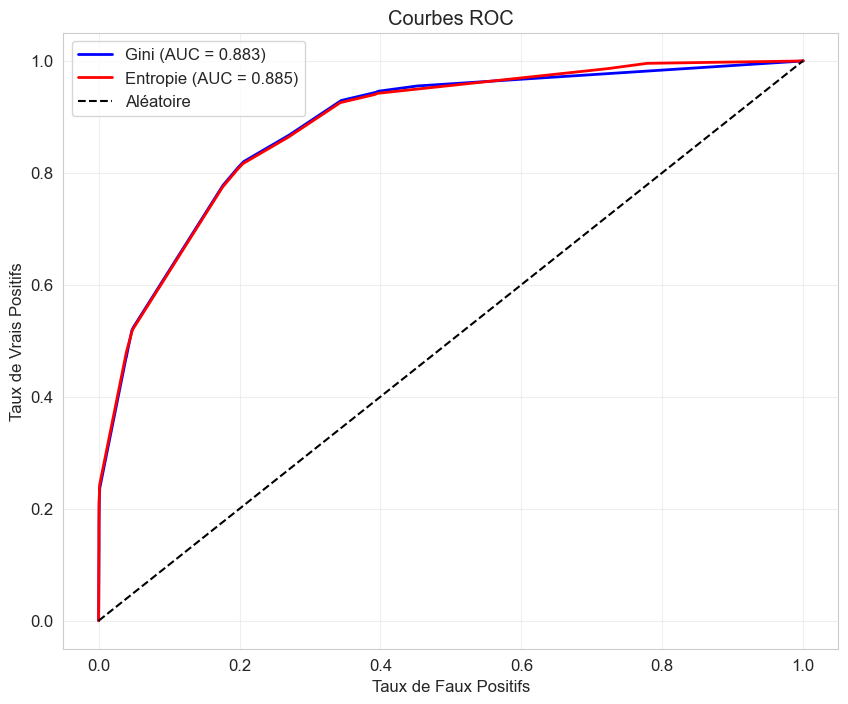

In [ ]:

plt.figure(figsize=(10, 8)) 
fpr_gini, tpr_gini, _ = roc_curve(y_test, y_proba_gini) 
auc_gini = auc(fpr_gini, tpr_gini) 
plt.plot(fpr_gini, tpr_gini, 'b-', linewidth=2, label=f'Gini (AUC = {auc_gini:.3f})') 
fpr_entropy, tpr_entropy, _ = roc_curve(y_test, y_proba_entropy) 
auc_entropy = auc(fpr_entropy, tpr_entropy) 
plt.plot(fpr_entropy, tpr_entropy, 'r-', linewidth=2, label=f'Entropie (AUC = {auc_entropy:.3f})') 
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire') 
plt.xlabel('Taux de Faux Positifs') 
plt.ylabel('Taux de Vrais Positifs') 
plt.title('Courbes ROC') 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.show()  

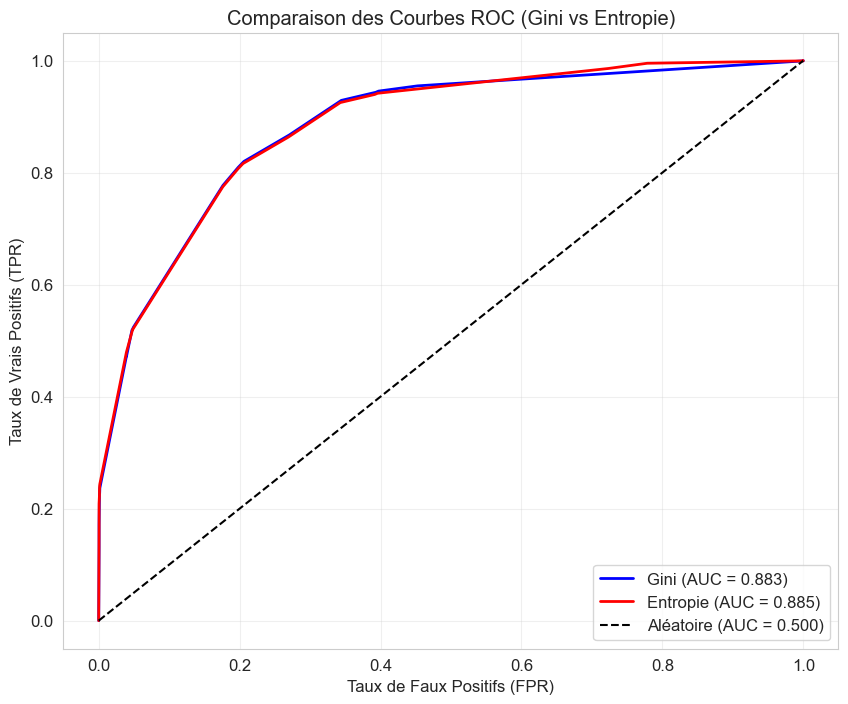

In [25]:
# --- PHASE 3 : ÉVALUATION APPROFONDIE ---
# 3. Courbes ROC

plt.figure(figsize=(10, 8)) 

# Calcul et tracé pour le modèle Gini
fpr_gini, tpr_gini, _ = roc_curve(y_test, y_proba_gini) 
auc_gini = auc(fpr_gini, tpr_gini) 
plt.plot(fpr_gini, tpr_gini, 'b-', linewidth=2, label=f'Gini (AUC = {auc_gini:.3f})') 

# Calcul et tracé pour le modèle Entropie
fpr_entropy, tpr_entropy, _ = roc_curve(y_test, y_proba_entropy) 
auc_entropy = auc(fpr_entropy, tpr_entropy) 
plt.plot(fpr_entropy, tpr_entropy, 'r-', linewidth=2, label=f'Entropie (AUC = {auc_entropy:.3f})') 

# Ligne de base (modèle aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.500)') 

# Configuration du graphique
plt.xlabel('Taux de Faux Positifs (FPR)') 
plt.ylabel('Taux de Vrais Positifs (TPR)') 
plt.title('Comparaison des Courbes ROC (Gini vs Entropie)') 
plt.legend(loc='lower right') 
plt.grid(True, alpha=0.3) 
plt.show()

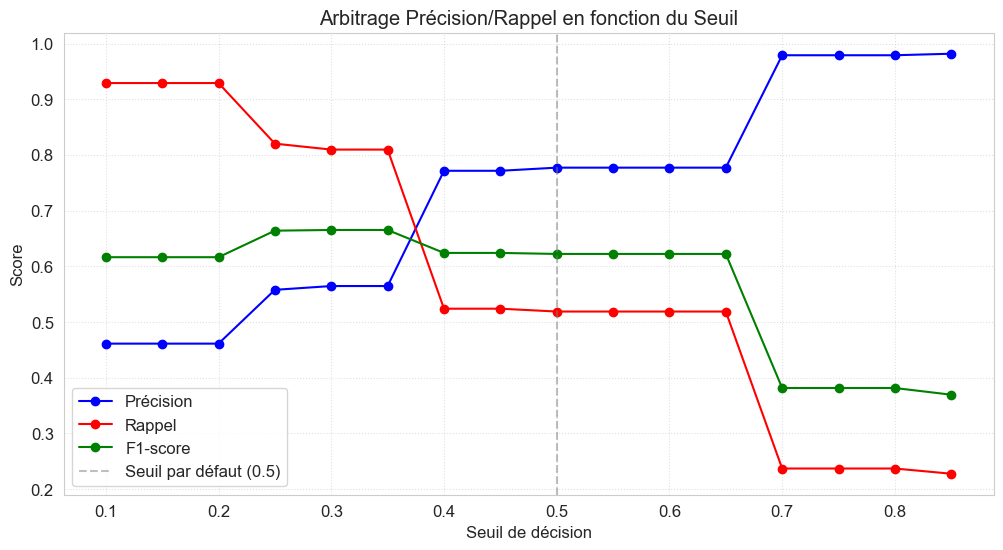

In [26]:
# --- PHASE 3 : ÉVALUATION APPROFONDIE ---
# 5. Impact du seuil de décision 

# Définition de la plage de seuils (de 0.1 à 0.85 avec un pas de 0.05)
seuils = np.arange(0.1, 0.9, 0.05) 
precisions, recalls, f1_scores = [], [], [] 

for s in seuils: 
    # Conversion des probabilités en prédictions binaires selon le seuil s
    y_pred = (y_proba_gini >= s).astype(int) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0)) 
    recalls.append(recall_score(y_test, y_pred)) 
    f1_scores.append(f1_score(y_test, y_pred)) 

# Visualisation des résultats
plt.figure(figsize=(12, 6)) 
plt.plot(seuils, precisions, 'b-o', label='Précision') 
plt.plot(seuils, recalls, 'r-o', label='Rappel') 
plt.plot(seuils, f1_scores, 'g-o', label='F1-score') 

# Ligne de repère pour le seuil standard de 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil par défaut (0.5)') 

plt.xlabel('Seuil de décision') 
plt.ylabel('Score') 
plt.title('Arbitrage Précision/Rappel en fonction du Seuil') 
plt.legend() 
plt.grid(True, linestyle=':', alpha=0.6) 
plt.show()

In [29]:
# --- PHASE 3 : ÉVALUATION APPROFONDIE ---
# 6. Validation croisée

# Définition des métriques à évaluer
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'} 

# Validation croisée 5-fold pour le modèle Gini
cv_gini = cross_validate(DecisionTreeClassifier(max_depth=5, random_state=42), 
                         X_train, y_train, cv=5, scoring=scoring) 

# Validation croisée 5-fold pour le modèle Entropie
cv_entropy = cross_validate(DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42), 
                            X_train, y_train, cv=5, scoring=scoring) 

# Affichage des résultats avec calcul de la moyenne et de l'intervalle de confiance (std*2)
for metrique in ['accuracy', 'precision', 'recall', 'f1']: 
    print(f"\n{metrique.upper()}:") 
    print(f"  Gini     : {cv_gini[f'test_{metrique}'].mean():.4f} (+/- {cv_gini[f'test_{metrique}'].std()*2:.4f})") 
    print(f"  Entropie : {cv_entropy[f'test_{metrique}'].mean():.4f} (+/- {cv_entropy[f'test_{metrique}'].std()*2:.4f})")


ACCURACY:
  Gini     : 0.8475 (+/- 0.0081)
  Entropie : 0.8463 (+/- 0.0092)

PRECISION:
  Gini     : 0.7779 (+/- 0.0149)
  Entropie : 0.7776 (+/- 0.0250)

RECALL:
  Gini     : 0.5136 (+/- 0.0413)
  Entropie : 0.5067 (+/- 0.0391)

F1:
  Gini     : 0.6185 (+/- 0.0310)
  Entropie : 0.6133 (+/- 0.0310)
